# Financial Eligibility Risk Modeling

In [1]:
#imports

!pip install imblearn
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from keras.callbacks import EarlyStopping

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 258 kB 16.3 MB/s            
     |████████████████████████████████| 258 kB 44.8 MB/s            
     |████████████████████████████████| 257 kB 35.5 MB/s            
     |████████████████████████████████| 257 kB 35.4 MB/s            
     |████████████████████████████████| 257 kB 44.6 MB/s            
     |████████████████████████████████| 235 kB 40.7 MB/s            
     |████████████████████████████████| 226 kB 35.1 MB/s            
     |████████████████████████████████| 225 kB 13.4 MB/s            
     |████████████████████████████████| 199 kB 55.4 MB/s            
     |████████████████████████████████| 199 kB 46.1 MB/s            
     |████████████████████████████████| 189 kB 38.8 MB/s            
     |████████████████████████████████| 22.2 MB 19.3 MB/s            


Matplotlib is building the font cache; this may take a moment.


In [2]:
# File paths for both data sets

census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


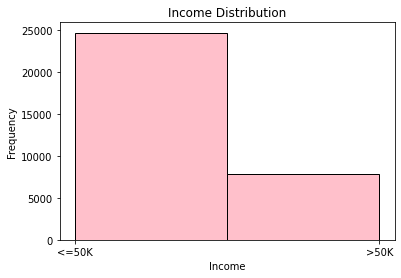

In [3]:
#the dataset shows massive class imbalance here, which will be fixed later on

plt.hist(df['income_binary'], bins=2, color='pink', edgecolor='black')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')

#displays the data types of each variable within df


df.dtypes

df.describe()


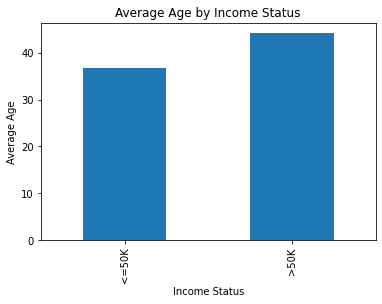

In [4]:
#analyzing the data with bar chart

df.groupby('income_binary')['age'].mean().plot(kind='bar')
plt.title('Average Age by Income Status')
plt.xlabel('Income Status')
plt.ylabel('Average Age')
plt.show()


In [5]:
#This section prepares the data for modeling

df['age'].fillna(df['age'].median(), inplace=True)
df['hours-per-week'].fillna(df['hours-per-week'].median(), inplace=True)

df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)
df['occupation'].fillna(df['occupation'].mode()[0], inplace=True)
df['native-country'].fillna(df['native-country'].mode()[0], inplace=True)
df.drop(columns='fnlwgt', inplace=True)
df.isnull().sum()

age               0
workclass         0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex_selfID        0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income_binary     0
dtype: int64

In [6]:
# Created labeled examples from the dataset

categorical_cols = [
    'workclass',
    'occupation',
    'education',
    'marital-status',
    'relationship',
    'race',
    'sex_selfID',
    'native-country'
]

In [7]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [8]:
# Created training and test sets out of the labeled examples 
df['income_binary'] = df['income_binary'].replace({'<=50K': 0,'>50K': 1})

X = df.drop('income_binary', axis=1)
y = df['income_binary']

# Used sci-kit learn to perform an 80-20 train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train),y=y_train)
class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: 0.6585094549499444, 1: 2.07719298245614}


In [10]:
# Performed model selection through grid search cross-validation (GridSearchCV)

gdt = DecisionTreeClassifier()
param_grid = {'max_depth': [5, 10, 15, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

grid_search = GridSearchCV(
    estimator=gdt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [11]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')

print("Accuracy:", accuracy)
print("F1 Score:", f1)
accu = accuracy
f1sc = f1


Accuracy: 0.8581298940580377
F1 Score: 0.6688172043010753


In [12]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                              Feature  Importance
41  marital-status_Married-civ-spouse    0.391804
1                       education-num    0.209457
2                        capital-gain    0.192381
3                        capital-loss    0.062476
0                                 age    0.051248
4                      hours-per-week    0.036199
14         occupation_Exec-managerial    0.011876
55              sex_selfID_Non-Female    0.005859
9          workclass_Self-emp-not-inc    0.005716
20          occupation_Prof-specialty    0.004832


In [13]:
# Scaling the data for the neural network

scaler = StandardScaler()

# Fit the scaler on the training data and transformed the training data

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
#number of features in your training data
n_features = X_train_scaled.shape[1]

print(X_train.shape)

# Created the neural network model
nn_model = keras.Sequential()

# Created the input layer and added the input layer to the model 
input_layer = keras.layers.InputLayer(input_shape=(96,), name='input')
nn_model.add(input_layer)

# Created the hidden layers

hidden_layer_1 = keras.layers.Dense(units=64, activation='relu', name='hl_1')
nn_model.add(hidden_layer_1)

hidden_layer_2 = keras.layers.Dense(units=32, activation='relu', name='hl_2')
nn_model.add(hidden_layer_2)

hidden_layer_3 = keras.layers.Dense(units=16, activation='relu', name='hl_3')
nn_model.add(hidden_layer_3)

# Created the output layer

output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output') 
nn_model.add(output_layer)

nn_model.summary()

(26048, 96)
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
hl_1 (Dense)                 (None, 64)                6208      
_________________________________________________________________
hl_2 (Dense)                 (None, 32)                2080      
_________________________________________________________________
hl_3 (Dense)                 (None, 16)                528       
_________________________________________________________________
output (Dense)               (None, 1)                 17        
Total params: 8,833
Trainable params: 8,833
Non-trainable params: 0
_________________________________________________________________


In [15]:
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.001)
#I chose .001 as it is the most common and it performed far better than .1 when I attempted it. 


In [16]:
#loss function

loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)


In [17]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

In [18]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

In [19]:
#fitting the model

t0 = time.time() # start time

num_epochs = 100

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#reserves a portion of my training data for validation during training
#helps with detecting overfitting
history = nn_model.fit(X_train, y_train, epochs=num_epochs, verbose=0,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)], validation_split=0.2
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

# i set the num_epochs to 100 because I think going above that is excessive, but when I was handling an error, chat informed me about early_stopping
#and I thought that was pretty clever, so I implemented that feature.


Epoch [10/ 100], Loss: 0.4823, Accuracy: 0.7827, Val_loss: 0.4859, Val_accuracy: 0.7846
Epoch [20/ 100], Loss: 0.4084, Accuracy: 0.7993, Val_loss: 0.4605, Val_accuracy: 0.7779
Epoch [30/ 100], Loss: 0.3840, Accuracy: 0.8131, Val_loss: 0.3720, Val_accuracy: 0.8015
Epoch [40/ 100], Loss: 0.3746, Accuracy: 0.8195, Val_loss: 0.3584, Val_accuracy: 0.8311
Epoch [50/ 100], Loss: 0.3693, Accuracy: 0.8235, Val_loss: 0.6367, Val_accuracy: 0.5553
Epoch [60/ 100], Loss: 0.3622, Accuracy: 0.8265, Val_loss: 0.3886, Val_accuracy: 0.8046
Epoch [70/ 100], Loss: 0.3604, Accuracy: 0.8286, Val_loss: 0.3556, Val_accuracy: 0.8234
Epoch [80/ 100], Loss: 0.3574, Accuracy: 0.8315, Val_loss: 0.3927, Val_accuracy: 0.8069
Epoch [90/ 100], Loss: 0.3558, Accuracy: 0.8316, Val_loss: 0.3651, Val_accuracy: 0.8203
Epoch [100/ 100], Loss: 0.3537, Accuracy: 0.8342, Val_loss: 0.3439, Val_accuracy: 0.8411
Elapsed time: 187.73s


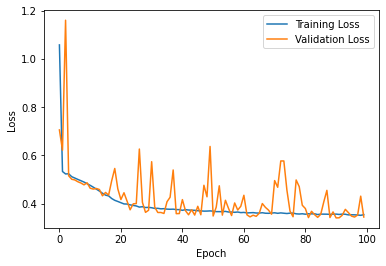

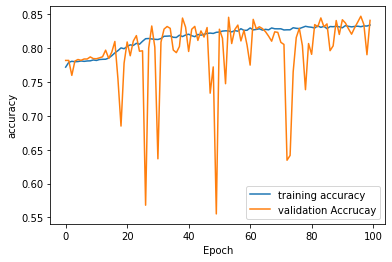

In [20]:
#Training loss and validation loss over epochs

plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Training accuracy and validation accuracy over epochs

plt.plot(history.history['accuracy'], label = 'training accuracy')
plt.plot(history.history['val_accuracy'], label = "validation Accrucay")
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()


In [24]:
# Generates predictions from the neural network using the scaled test data
# predictions > .5 used for class labels
predictions = nn_model.predict(X_test)
predicted_classes = (predictions > 0.5).astype("int32")

In [25]:
# Computes accuracy and F1 score for the neural network and prints the results

model_accuracy = accuracy_score(y_test, predicted_classes)
model_f1 = f1_score(y_test, predicted_classes, average='binary')

print(model_accuracy)
print(model_f1)

0.8366344234607708
0.6102564102564102


In [26]:
# side-by-side comparison of the DT and Neural Network models

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
     'Decision Tree': [accuracy, f1],
     'Neural Network': [model_accuracy, model_f1]
 })

print(results.to_string(index=False))

   Metric  Decision Tree  Neural Network
 Accuracy       0.858130        0.836634
 F1 Score       0.668817        0.610256
